# Validation plots

This notebook loads two JSON reports: one for `core` only and one for the `core` vs `interaction` comparison. The figures are already visible here, and every plot can be regenerated from the JSON files.

In [1]:
from pathlib import Path
import json
import math
import os
import statistics


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "run_experiment.py").exists() and (candidate / "artifacts").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or from notebooks/.")

ROOT = find_project_root(Path.cwd())
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "tmp" / "mpl"))
os.environ.setdefault("XDG_CACHE_HOME", str(ROOT / "tmp" / "cache"))
os.environ.setdefault("FC_CACHEDIR", str(ROOT / "tmp" / "cache" / "fontconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["FC_CACHEDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

CORE_REPORT_PATH = ROOT / "artifacts" / "core" / "core_only.json"
COMPARISON_REPORT_PATH = ROOT / "artifacts" / "comparison_core_and_interaction" / "core_vs_interaction.json"

with CORE_REPORT_PATH.open(encoding="utf-8") as handle:
    core = json.load(handle)
with COMPARISON_REPORT_PATH.open(encoding="utf-8") as handle:
    comparison = json.load(handle)

core_runs = core["runs"]
core_summary = core["summary"]
core_progress = core["progress"]
comparison_runs = comparison["runs"]
comparison_summary = comparison["summary"]
feature_order = [feature for feature in ("core", "interaction") if any(row["feature_set"] == feature for row in comparison_runs)]
profile_order = [profile for profile in ("aggressive", "conservative", "greedy_points") if any(row["profile"] == profile for row in comparison_runs)]
colors = {"core": "#2f6f3e", "interaction": "#b8792b"}
profile_colors = {"aggressive": "#2f6f3e", "conservative": "#3b6fb6", "greedy_points": "#b8792b"}

print(f"Loaded {CORE_REPORT_PATH.relative_to(ROOT)}")
print(f"Loaded {COMPARISON_REPORT_PATH.relative_to(ROOT)}")
print(f"core runs: {len(core_runs)}")
print(f"comparison runs: {len(comparison_runs)}")
print(f"feature sets: {', '.join(feature_order)}")


Loaded artifacts/core/core_only.json
Loaded artifacts/comparison_core_and_interaction/core_vs_interaction.json
core runs: 9
comparison runs: 18
feature sets: core, interaction


In [2]:
def metric(row, key):
    value = row.get(key)
    if value is None:
        return math.nan
    return float(value)


def mean_stdev(values):
    if not values:
        return math.nan, math.nan
    if len(values) == 1:
        return values[0], 0.0
    return statistics.fmean(values), statistics.stdev(values)


def grouped_summary(rows):
    return {(row["feature_set"], row["profile"]): row for row in rows}


## Core only

This section checks the compact `core` feature set on its own.

In [3]:
from IPython.display import HTML, display


def show_summary(rows):
    rows = sorted(rows, key=lambda item: (item["feature_set"], item["profile"]))
    rendered = []
    for row in rows:
        rendered.append(
            {
                "feature_set": row["feature_set"],
                "profile": row["profile"],
                "runs": row["runs"],
                "theta L2": f"{metric(row, 'theta_l2_error_mean'):.3f}",
                "mean logp delta": f"{metric(row, 'test_mean_logp_delta_mean'):.4f}",
                "loglik delta": f"{metric(row, 'test_loglik_delta_mean'):.3f}",
                "final ELBO": f"{metric(row, 'final_elbo_mean'):.1f}",
            }
        )
    header = "".join(f"<th>{name}</th>" for name in rendered[0])
    body = "".join(
        "<tr>" + "".join(f"<td>{value}</td>" for value in row.values()) + "</tr>"
        for row in rendered
    )
    display(HTML(
        """
        <style>
        table.briscola-summary {border-collapse: collapse; font-size: 13px;}
        table.briscola-summary th, table.briscola-summary td {border: 1px solid #ddd; padding: 6px 8px;}
        table.briscola-summary th {background: #f4f4f4; text-align: left;}
        table.briscola-summary td {text-align: right;}
        table.briscola-summary td:first-child, table.briscola-summary td:nth-child(2) {text-align: left;}
        </style>
        """
        + f"<table class='briscola-summary'><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"
    ))

show_summary(core_summary)


feature_set,profile,runs,theta L2,mean logp delta,loglik delta,final ELBO
core,aggressive,3,0.3312,0.0632,31.5948,-3654.9165
core,conservative,3,0.3094,0.0888,44.3828,-3609.6869
core,greedy_points,3,0.7372,0.0155,7.7278,-3708.4917


### Core performance by number of games

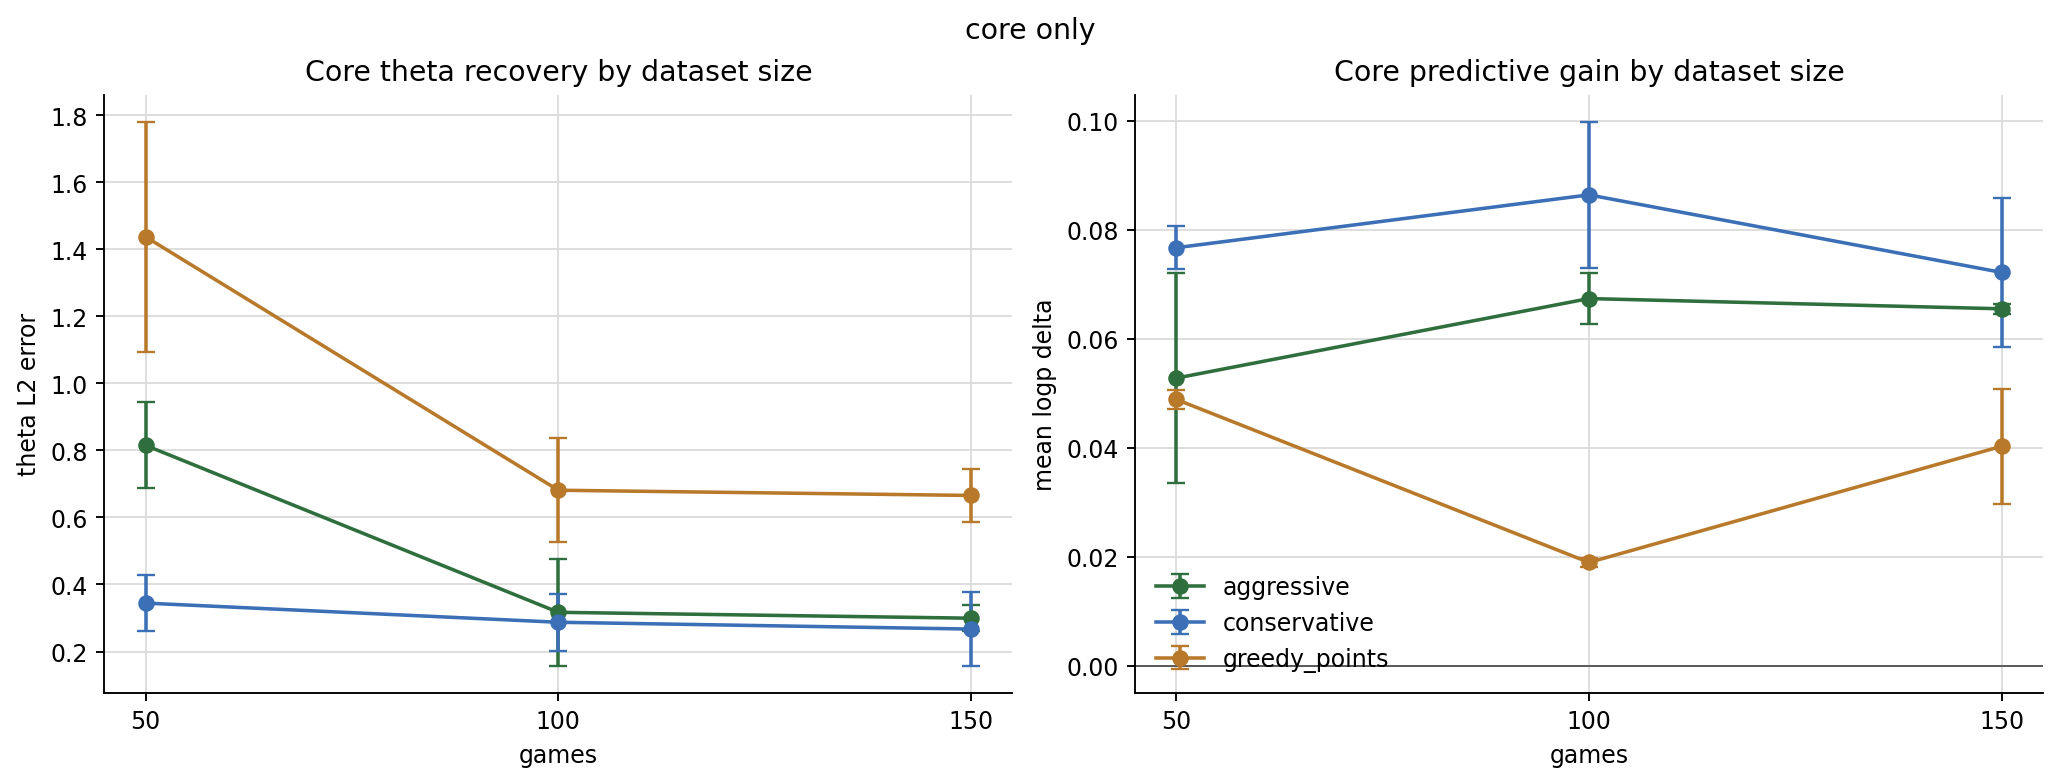

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for profile in profile_order:
    rows = sorted([row for row in core_progress if row["profile"] == profile], key=lambda row: row["num_games"])
    x = [row["num_games"] for row in rows]
    theta = [row["theta_l2_error_mean"] for row in rows]
    theta_std = [row["theta_l2_error_std"] for row in rows]
    logp = [row["heldout_mean_logp_delta_mean"] for row in rows]
    logp_std = [row["heldout_mean_logp_delta_std"] for row in rows]
    axes[0].errorbar(x, theta, yerr=theta_std, marker="o", capsize=4, color=profile_colors[profile], label=profile)
    axes[1].errorbar(x, logp, yerr=logp_std, marker="o", capsize=4, color=profile_colors[profile], label=profile)
axes[0].set_title("Core theta recovery by dataset size")
axes[0].set_xlabel("games")
axes[0].set_ylabel("theta L2 error")
axes[1].axhline(0.0, color="#555555", linewidth=0.8)
axes[1].set_title("Core predictive gain by dataset size")
axes[1].set_xlabel("games")
axes[1].set_ylabel("mean logp delta")
for ax in axes:
    ax.set_xticks(sorted({row["num_games"] for row in core_progress}))
    ax.grid(color="#dddddd", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False)
fig.suptitle("core only")
plt.show()


### Core profile summary at 100 games

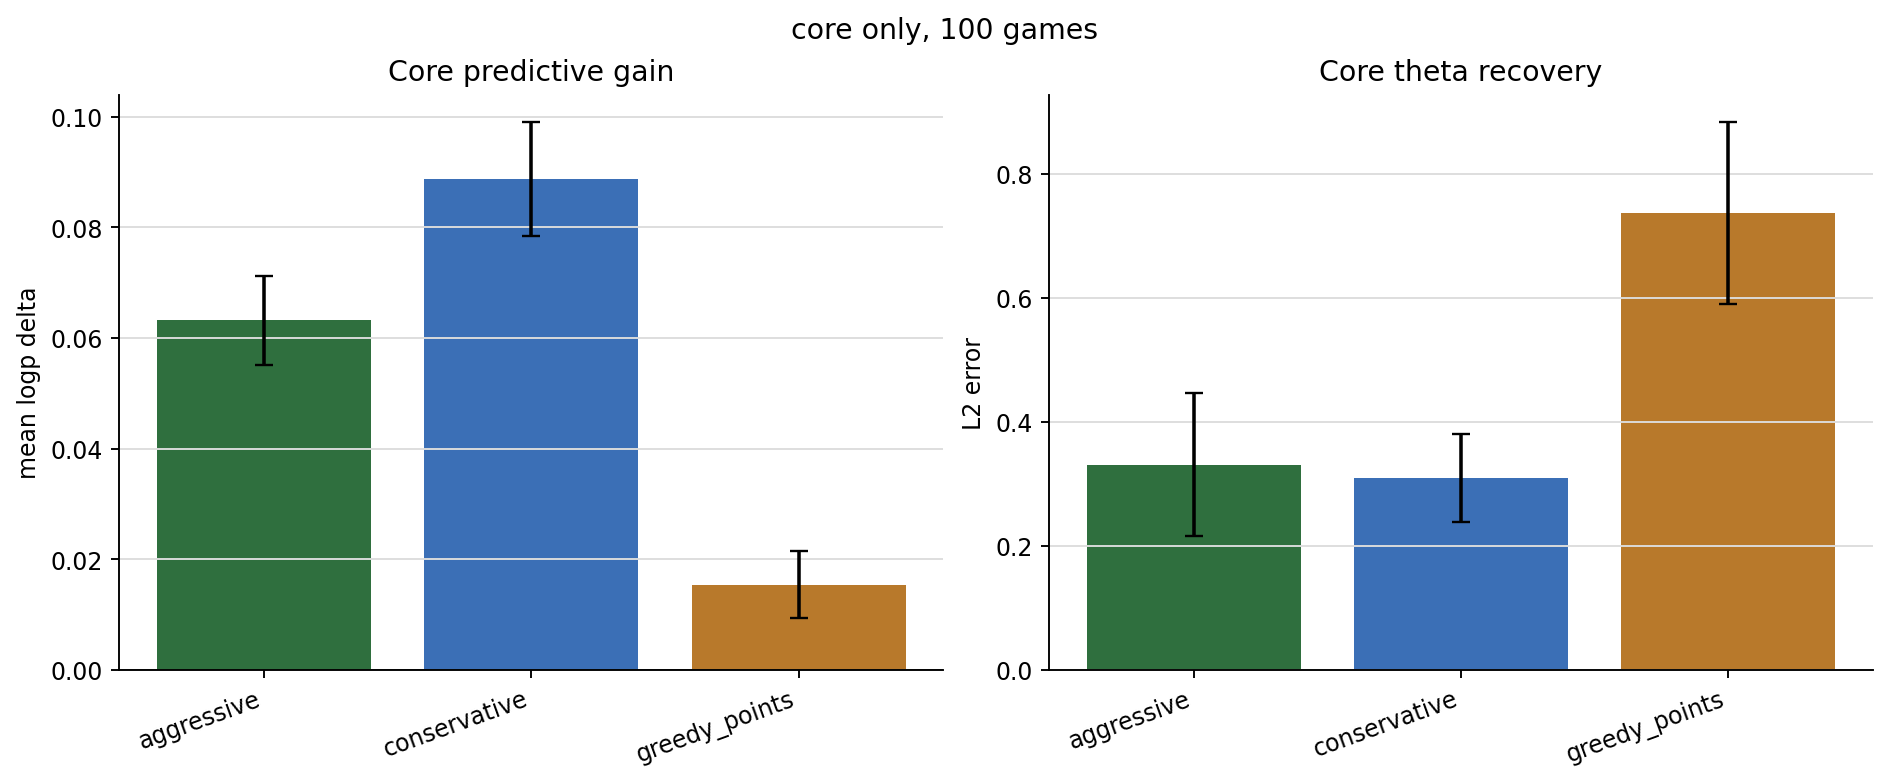

In [5]:
data = {row["profile"]: row for row in core_summary}
x = list(range(len(profile_order)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
logp = [metric(data[profile], "test_mean_logp_delta_mean") for profile in profile_order]
logp_std = [metric(data[profile], "test_mean_logp_delta_std") for profile in profile_order]
theta = [metric(data[profile], "theta_l2_error_mean") for profile in profile_order]
theta_std = [metric(data[profile], "theta_l2_error_std") for profile in profile_order]
axes[0].bar(x, logp, yerr=logp_std, capsize=4, color=[profile_colors[p] for p in profile_order])
axes[1].bar(x, theta, yerr=theta_std, capsize=4, color=[profile_colors[p] for p in profile_order])
axes[0].axhline(0.0, color="#555555", linewidth=0.8)
axes[0].set_title("Core predictive gain")
axes[0].set_ylabel("mean logp delta")
axes[1].set_title("Core theta recovery")
axes[1].set_ylabel("L2 error")
for ax in axes:
    ax.set_xticks(x, profile_order, rotation=20, ha="right")
    ax.grid(axis="y", color="#dddddd", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("core only, 100 games")
plt.show()


### Core ELBO optimization

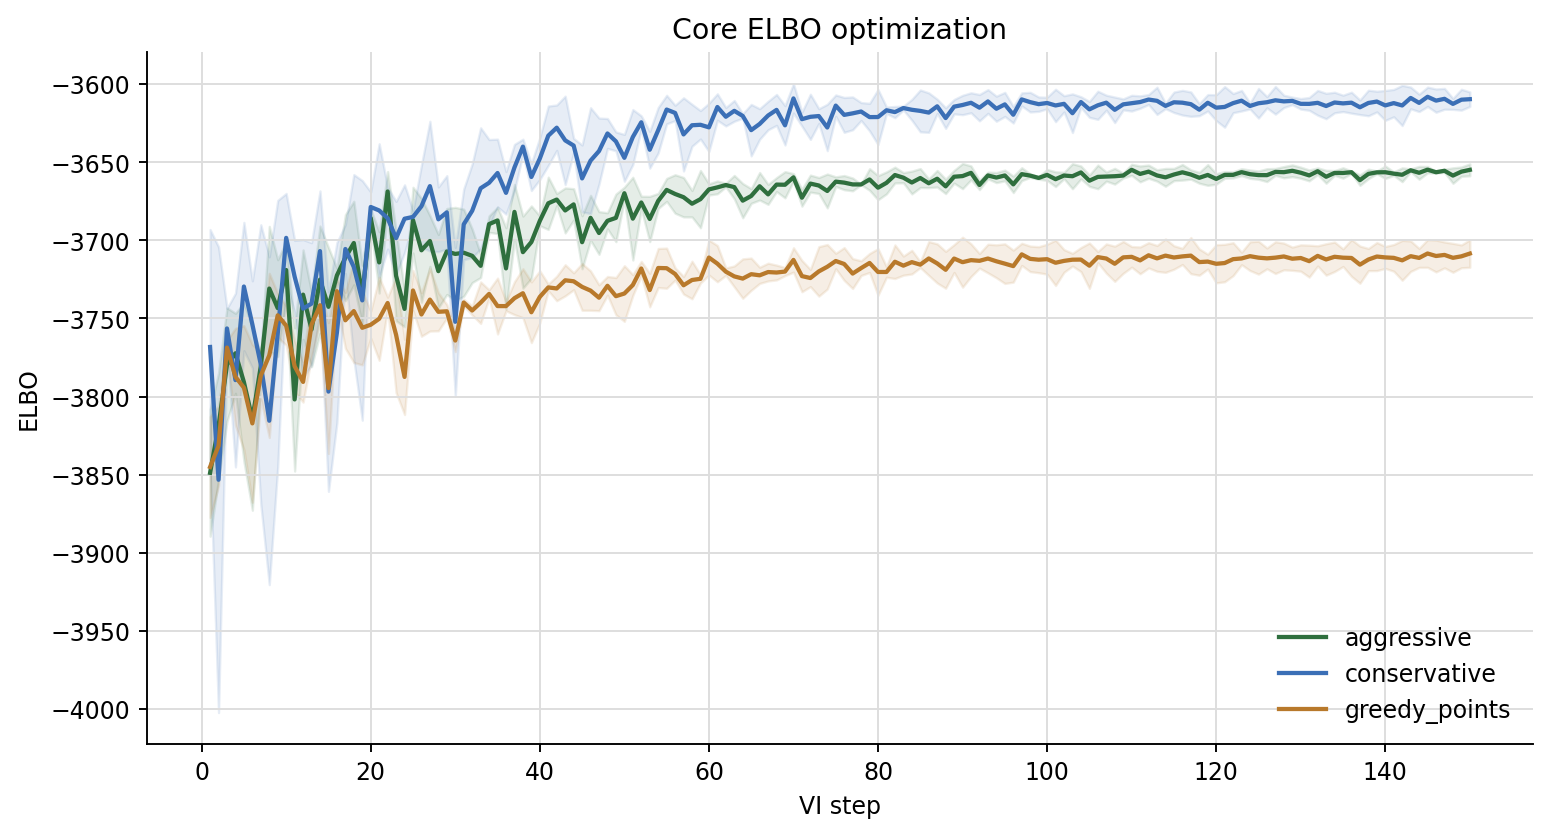

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
for profile in profile_order:
    selected = [row for row in core_runs if row["profile"] == profile and row.get("elbo_history")]
    if not selected:
        continue
    length = min(len(row["elbo_history"]) for row in selected)
    steps = list(range(1, length + 1))
    means = []
    stds = []
    for index in range(length):
        values = [float(row["elbo_history"][index]) for row in selected]
        mean, std = mean_stdev(values)
        means.append(mean)
        stds.append(std)
    ax.plot(steps, means, label=profile, color=profile_colors[profile], linewidth=1.8)
    ax.fill_between(steps, [m-s for m, s in zip(means, stds)], [m+s for m, s in zip(means, stds)], color=profile_colors[profile], alpha=0.12)
ax.set_title("Core ELBO optimization")
ax.set_xlabel("VI step")
ax.set_ylabel("ELBO")
ax.grid(color="#dddddd", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()


### Core theta recovery

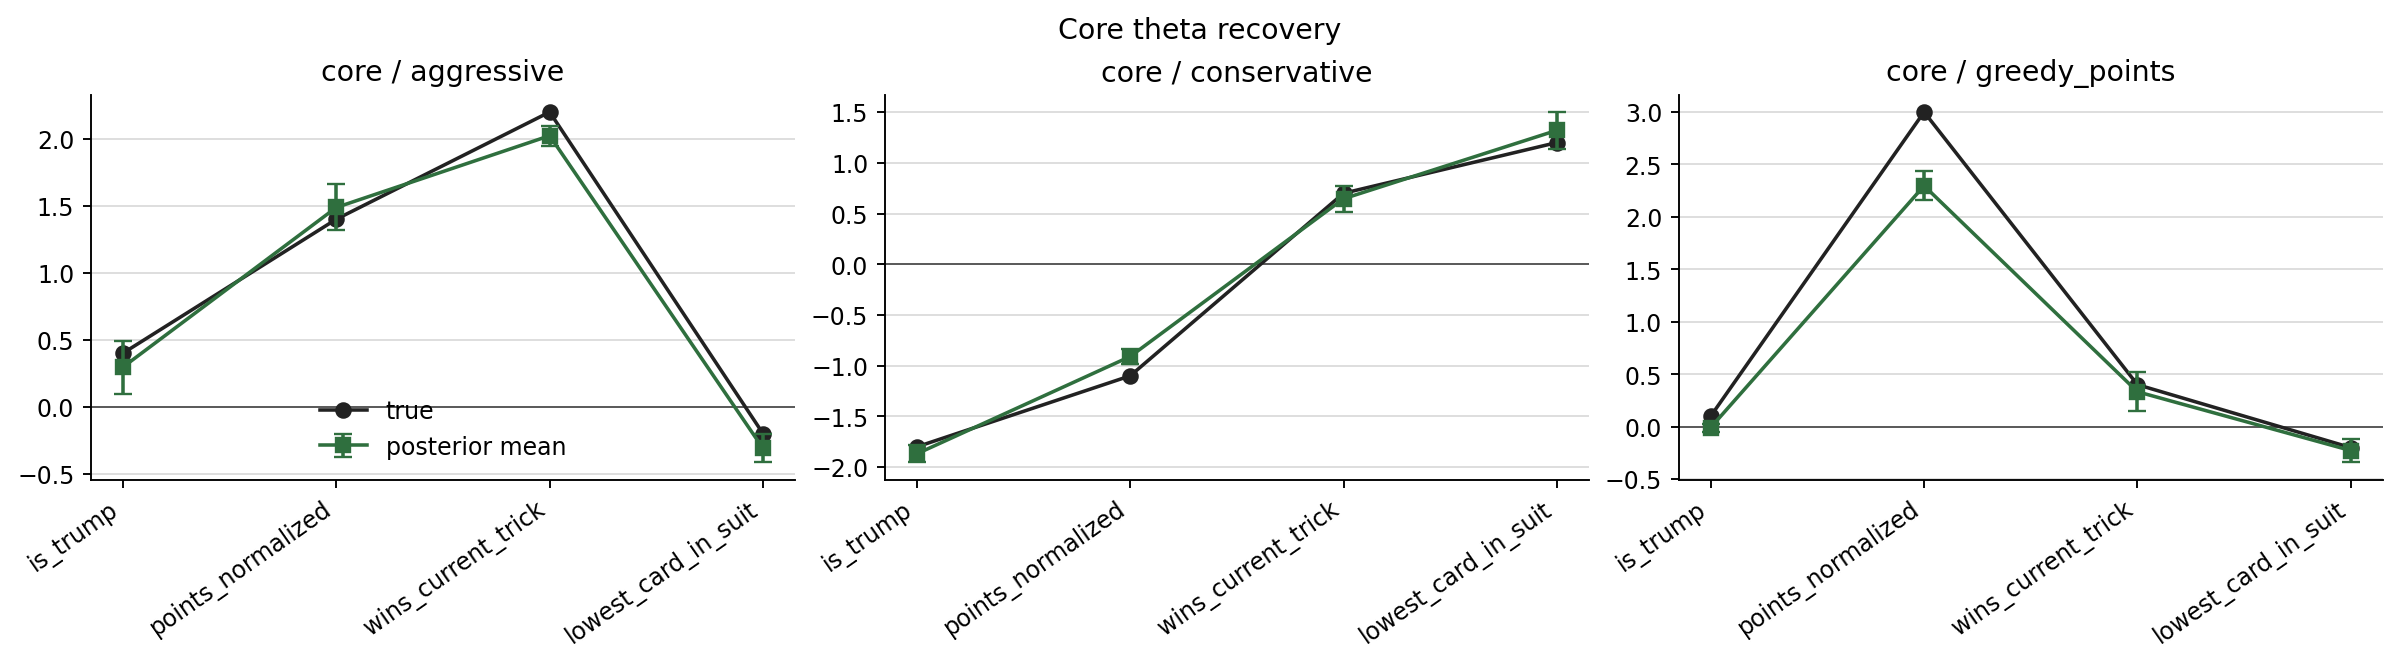

In [7]:
def plot_theta_recovery(rows, feature_sets, title):
    fig, axes = plt.subplots(len(feature_sets), len(profile_order), figsize=(14, 3.8 * len(feature_sets)), constrained_layout=True)
    if len(feature_sets) == 1:
        axes = [axes]
    for row_index, feature_set in enumerate(feature_sets):
        for col_index, profile in enumerate(profile_order):
            ax = axes[row_index][col_index]
            selected = [row for row in rows if row["feature_set"] == feature_set and row["profile"] == profile]
            if not selected:
                ax.axis("off")
                continue
            names = selected[0]["feature_names"]
            true = selected[0]["theta_true"]
            means = []
            stds = []
            for feature_index in range(len(names)):
                values = [float(row["theta_posterior_mean"][feature_index]) for row in selected]
                mean, std = mean_stdev(values)
                means.append(mean)
                stds.append(std)
            x = list(range(len(names)))
            ax.axhline(0.0, color="#555555", linewidth=0.8)
            ax.plot(x, true, marker="o", color="#222222", label="true")
            ax.errorbar(x, means, yerr=stds, marker="s", color=colors.get(feature_set, "#2f6f3e"), capsize=4, label="posterior mean")
            ax.set_title(f"{feature_set} / {profile}")
            ax.set_xticks(x, names, rotation=35, ha="right")
            ax.grid(axis="y", color="#dddddd", linewidth=0.8)
            ax.spines[["top", "right"]].set_visible(False)
            if row_index == 0 and col_index == 0:
                ax.legend(frameon=False)
    fig.suptitle(title)
    plt.show()

plot_theta_recovery(core_runs, ["core"], "Core theta recovery")


## Core vs interaction

This section compares `core` with the 4-feature `interaction` set.

In [8]:
show_summary(comparison_summary)


feature_set,profile,runs,theta L2,mean logp delta,loglik delta,final ELBO
core,aggressive,3,0.3312,0.0632,31.5948,-3654.9165
core,conservative,3,0.3094,0.0888,44.3828,-3609.6869
core,greedy_points,3,0.7372,0.0155,7.7278,-3708.4917
interaction,aggressive,3,1.0295,0.0473,23.6715,-3685.5651
interaction,conservative,3,0.8359,0.0185,9.2400,-3710.5260
interaction,greedy_points,3,0.6506,0.0296,14.8064,-3717.5315


### Comparison summary

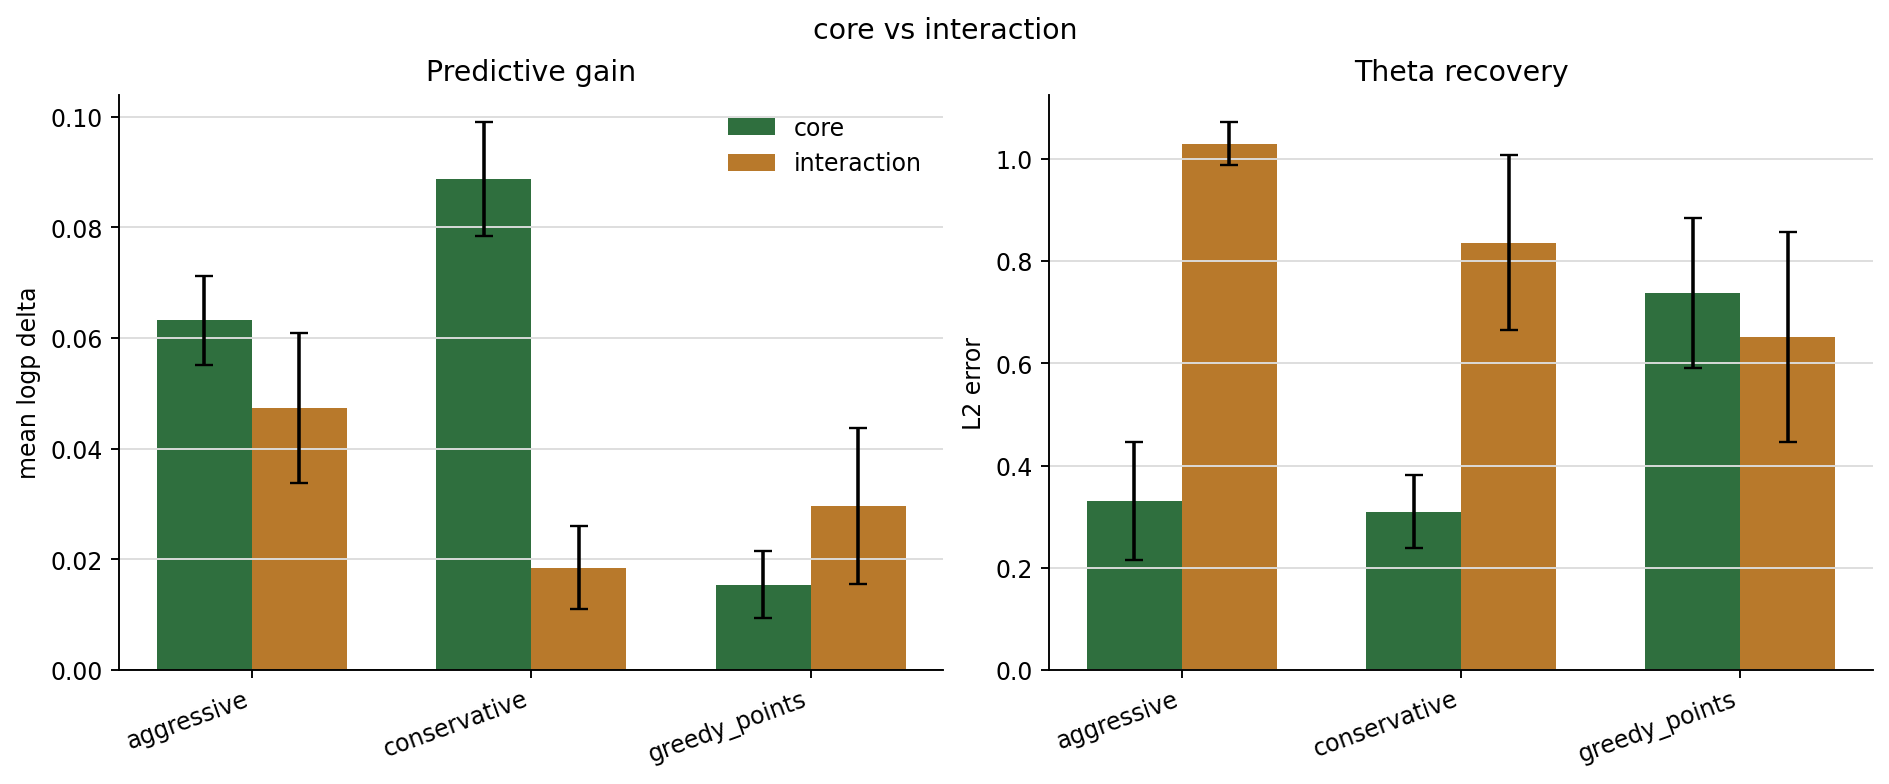

In [9]:
data = grouped_summary(comparison_summary)
width = 0.34
x = list(range(len(profile_order)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for offset_index, feature_set in enumerate(feature_order):
    offsets = [value + (offset_index - 0.5) * width for value in x]
    rows = [data[(feature_set, profile)] for profile in profile_order]
    logp = [metric(row, "test_mean_logp_delta_mean") for row in rows]
    logp_std = [metric(row, "test_mean_logp_delta_std") for row in rows]
    theta = [metric(row, "theta_l2_error_mean") for row in rows]
    theta_std = [metric(row, "theta_l2_error_std") for row in rows]
    axes[0].bar(offsets, logp, width, yerr=logp_std, capsize=4, color=colors[feature_set], label=feature_set)
    axes[1].bar(offsets, theta, width, yerr=theta_std, capsize=4, color=colors[feature_set], label=feature_set)
axes[0].axhline(0.0, color="#555555", linewidth=0.8)
axes[0].set_title("Predictive gain")
axes[0].set_ylabel("mean logp delta")
axes[1].set_title("Theta recovery")
axes[1].set_ylabel("L2 error")
for ax in axes:
    ax.set_xticks(x, profile_order, rotation=20, ha="right")
    ax.grid(axis="y", color="#dddddd", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
fig.suptitle("core vs interaction")
plt.show()


### Predictive gain by seed

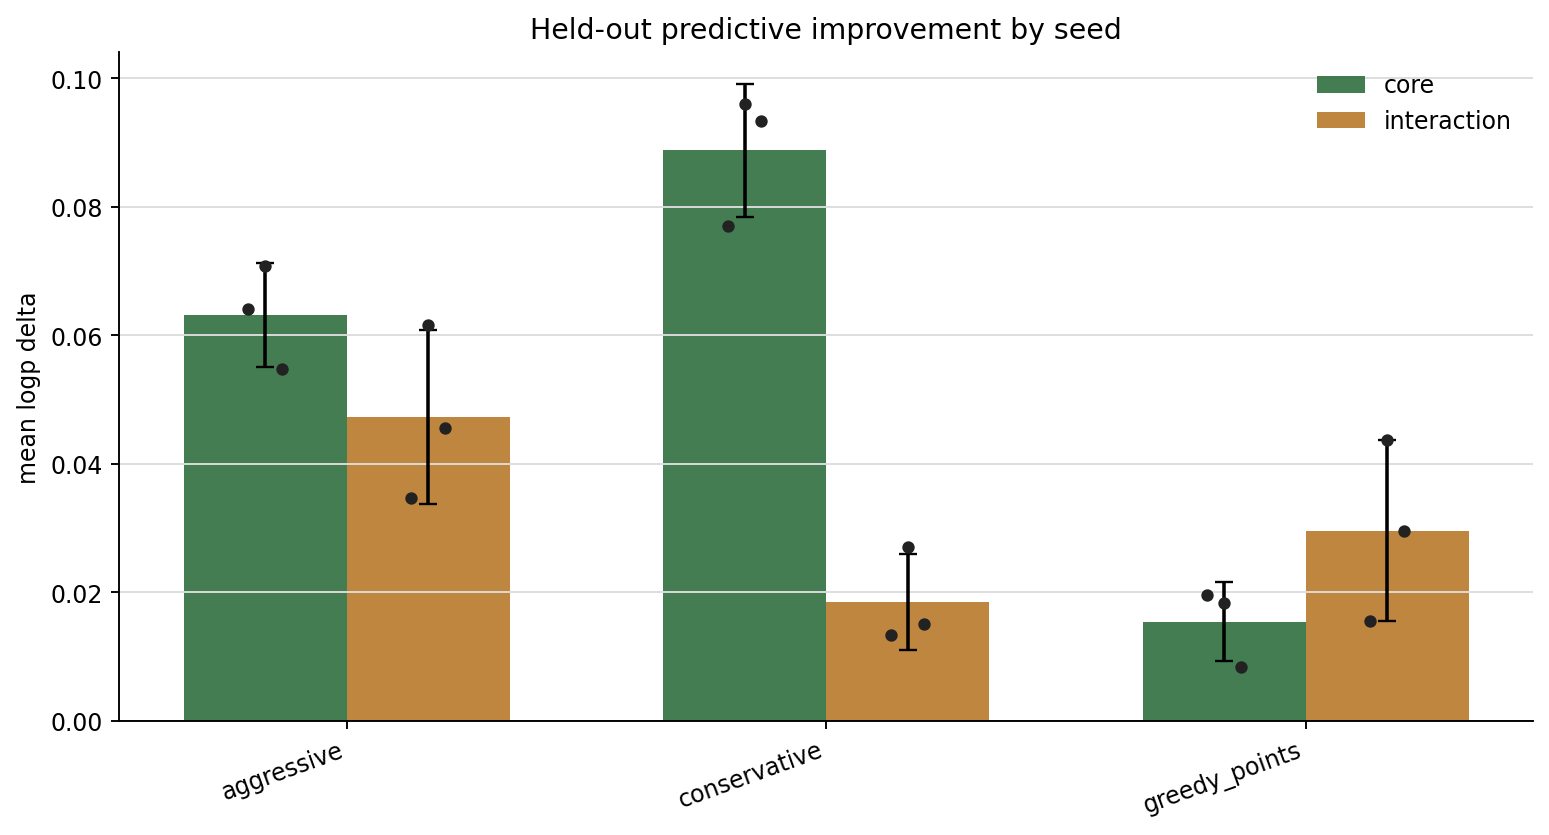

In [10]:
data = grouped_summary(comparison_summary)
fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
width = 0.34
x = list(range(len(profile_order)))
for offset_index, feature_set in enumerate(feature_order):
    offsets = [value + (offset_index - 0.5) * width for value in x]
    means = [metric(data[(feature_set, profile)], "test_mean_logp_delta_mean") for profile in profile_order]
    stds = [metric(data[(feature_set, profile)], "test_mean_logp_delta_std") for profile in profile_order]
    ax.bar(offsets, means, width, yerr=stds, capsize=4, color=colors[feature_set], label=feature_set, alpha=0.9)
    for profile, xpos in zip(profile_order, offsets):
        values = [metric(row, "test_mean_logp_delta") for row in comparison_runs if row["feature_set"] == feature_set and row["profile"] == profile]
        jitter = [-0.035, 0.0, 0.035, 0.07, -0.07]
        for index, value in enumerate(values):
            ax.scatter(xpos + jitter[index % len(jitter)], value, color="#222222", s=18, zorder=3)
ax.axhline(0.0, color="#555555", linewidth=0.8)
ax.set_title("Held-out predictive improvement by seed")
ax.set_ylabel("mean logp delta")
ax.set_xticks(x, profile_order, rotation=20, ha="right")
ax.grid(axis="y", color="#dddddd", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()


### Prediction vs recovery

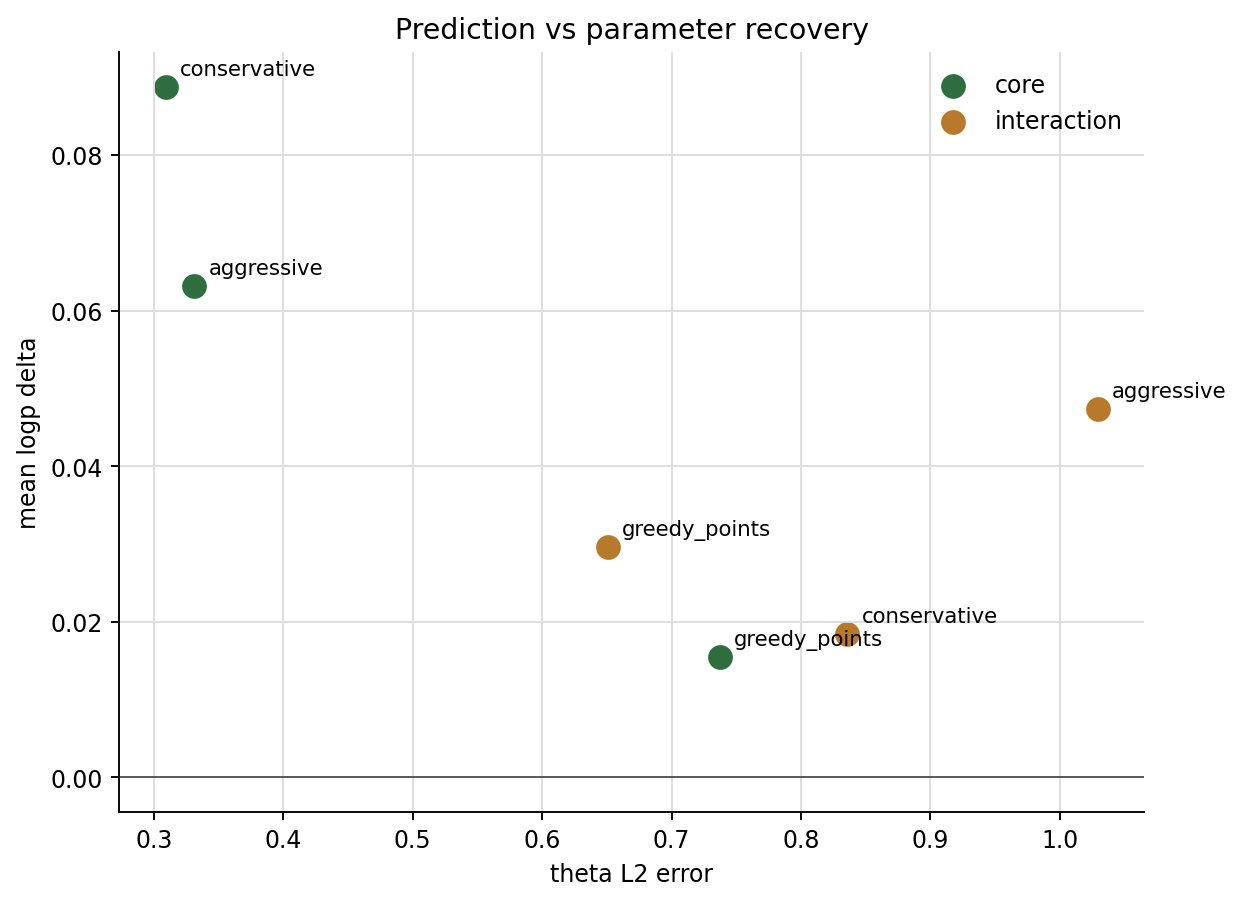

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
used_labels = set()
for row in comparison_summary:
    feature_set = row["feature_set"]
    x = metric(row, "theta_l2_error_mean")
    y = metric(row, "test_mean_logp_delta_mean")
    label = feature_set if feature_set not in used_labels else None
    used_labels.add(feature_set)
    ax.scatter(x, y, s=90, color=colors[feature_set], label=label)
    ax.annotate(row["profile"], (x, y), xytext=(6, 5), textcoords="offset points", fontsize=9)
ax.axhline(0.0, color="#555555", linewidth=0.8)
ax.set_title("Prediction vs parameter recovery")
ax.set_xlabel("theta L2 error")
ax.set_ylabel("mean logp delta")
ax.grid(color="#dddddd", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()


### Comparison ELBO optimization

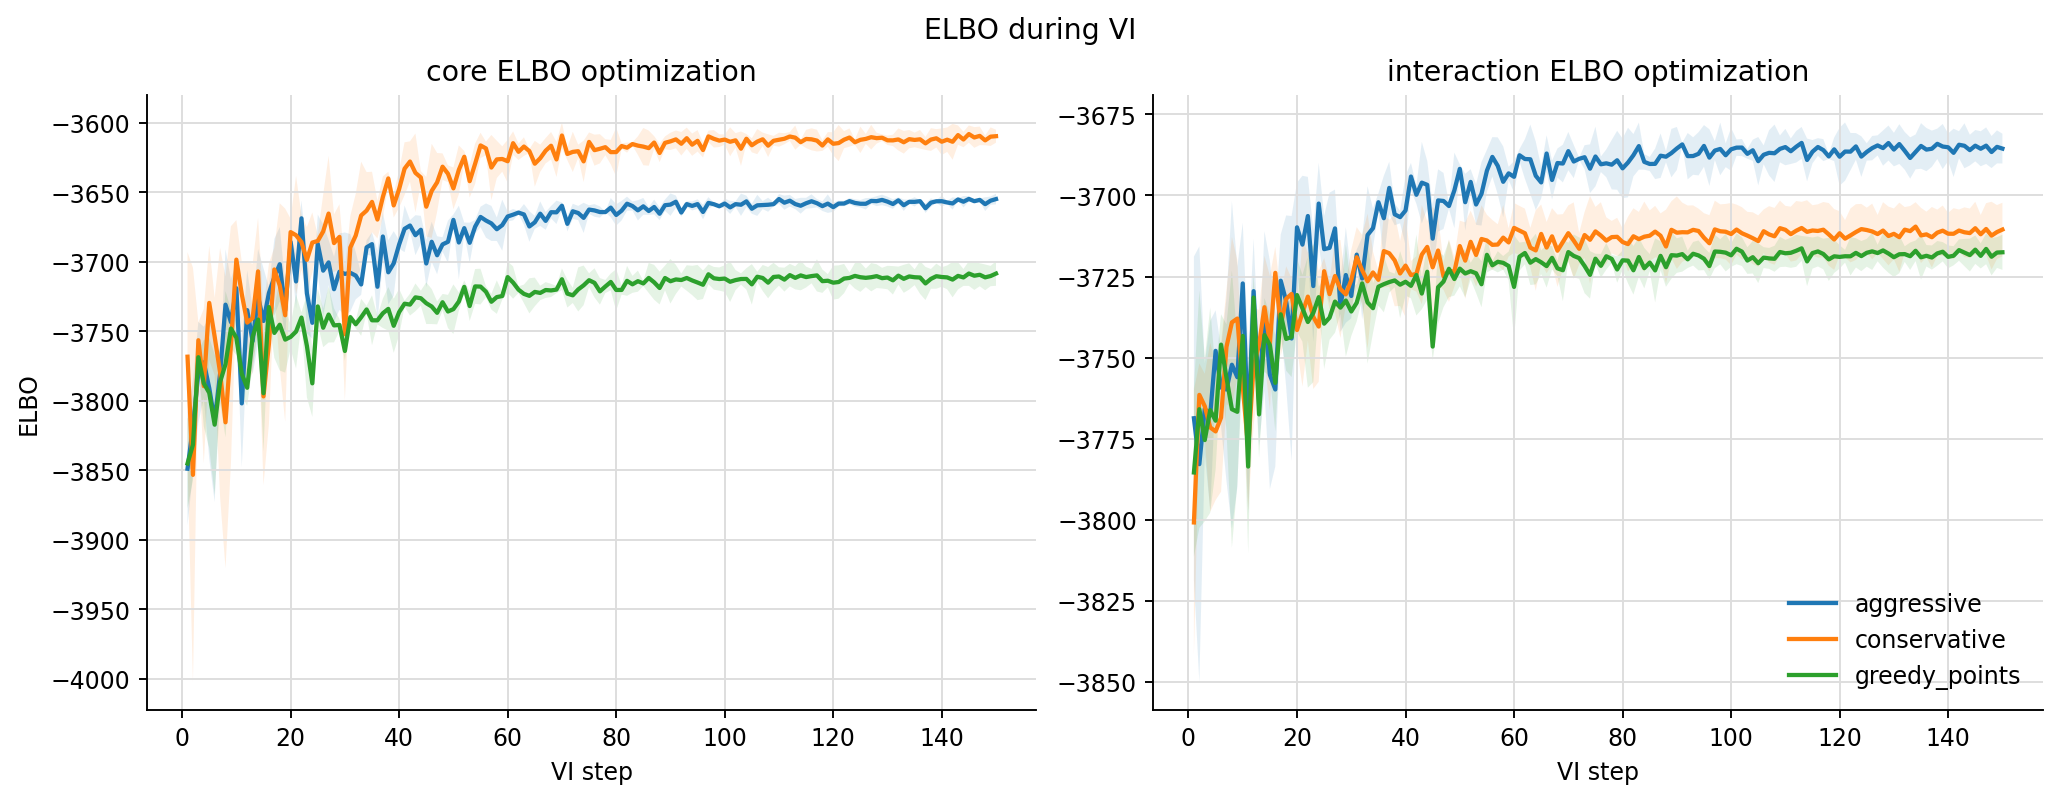

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
for ax, feature_set in zip(axes, feature_order):
    for profile in profile_order:
        selected = [row for row in comparison_runs if row["feature_set"] == feature_set and row["profile"] == profile and row.get("elbo_history")]
        if not selected:
            continue
        length = min(len(row["elbo_history"]) for row in selected)
        steps = list(range(1, length + 1))
        means = []
        stds = []
        for index in range(length):
            values = [float(row["elbo_history"][index]) for row in selected]
            mean, std = mean_stdev(values)
            means.append(mean)
            stds.append(std)
        ax.plot(steps, means, label=profile, linewidth=1.8)
        ax.fill_between(steps, [m-s for m, s in zip(means, stds)], [m+s for m, s in zip(means, stds)], alpha=0.12)
    ax.set_title(f"{feature_set} ELBO optimization")
    ax.set_xlabel("VI step")
    ax.grid(color="#dddddd", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("ELBO")
axes[-1].legend(frameon=False, loc="best")
fig.suptitle("ELBO during VI")
plt.show()


### Comparison theta recovery

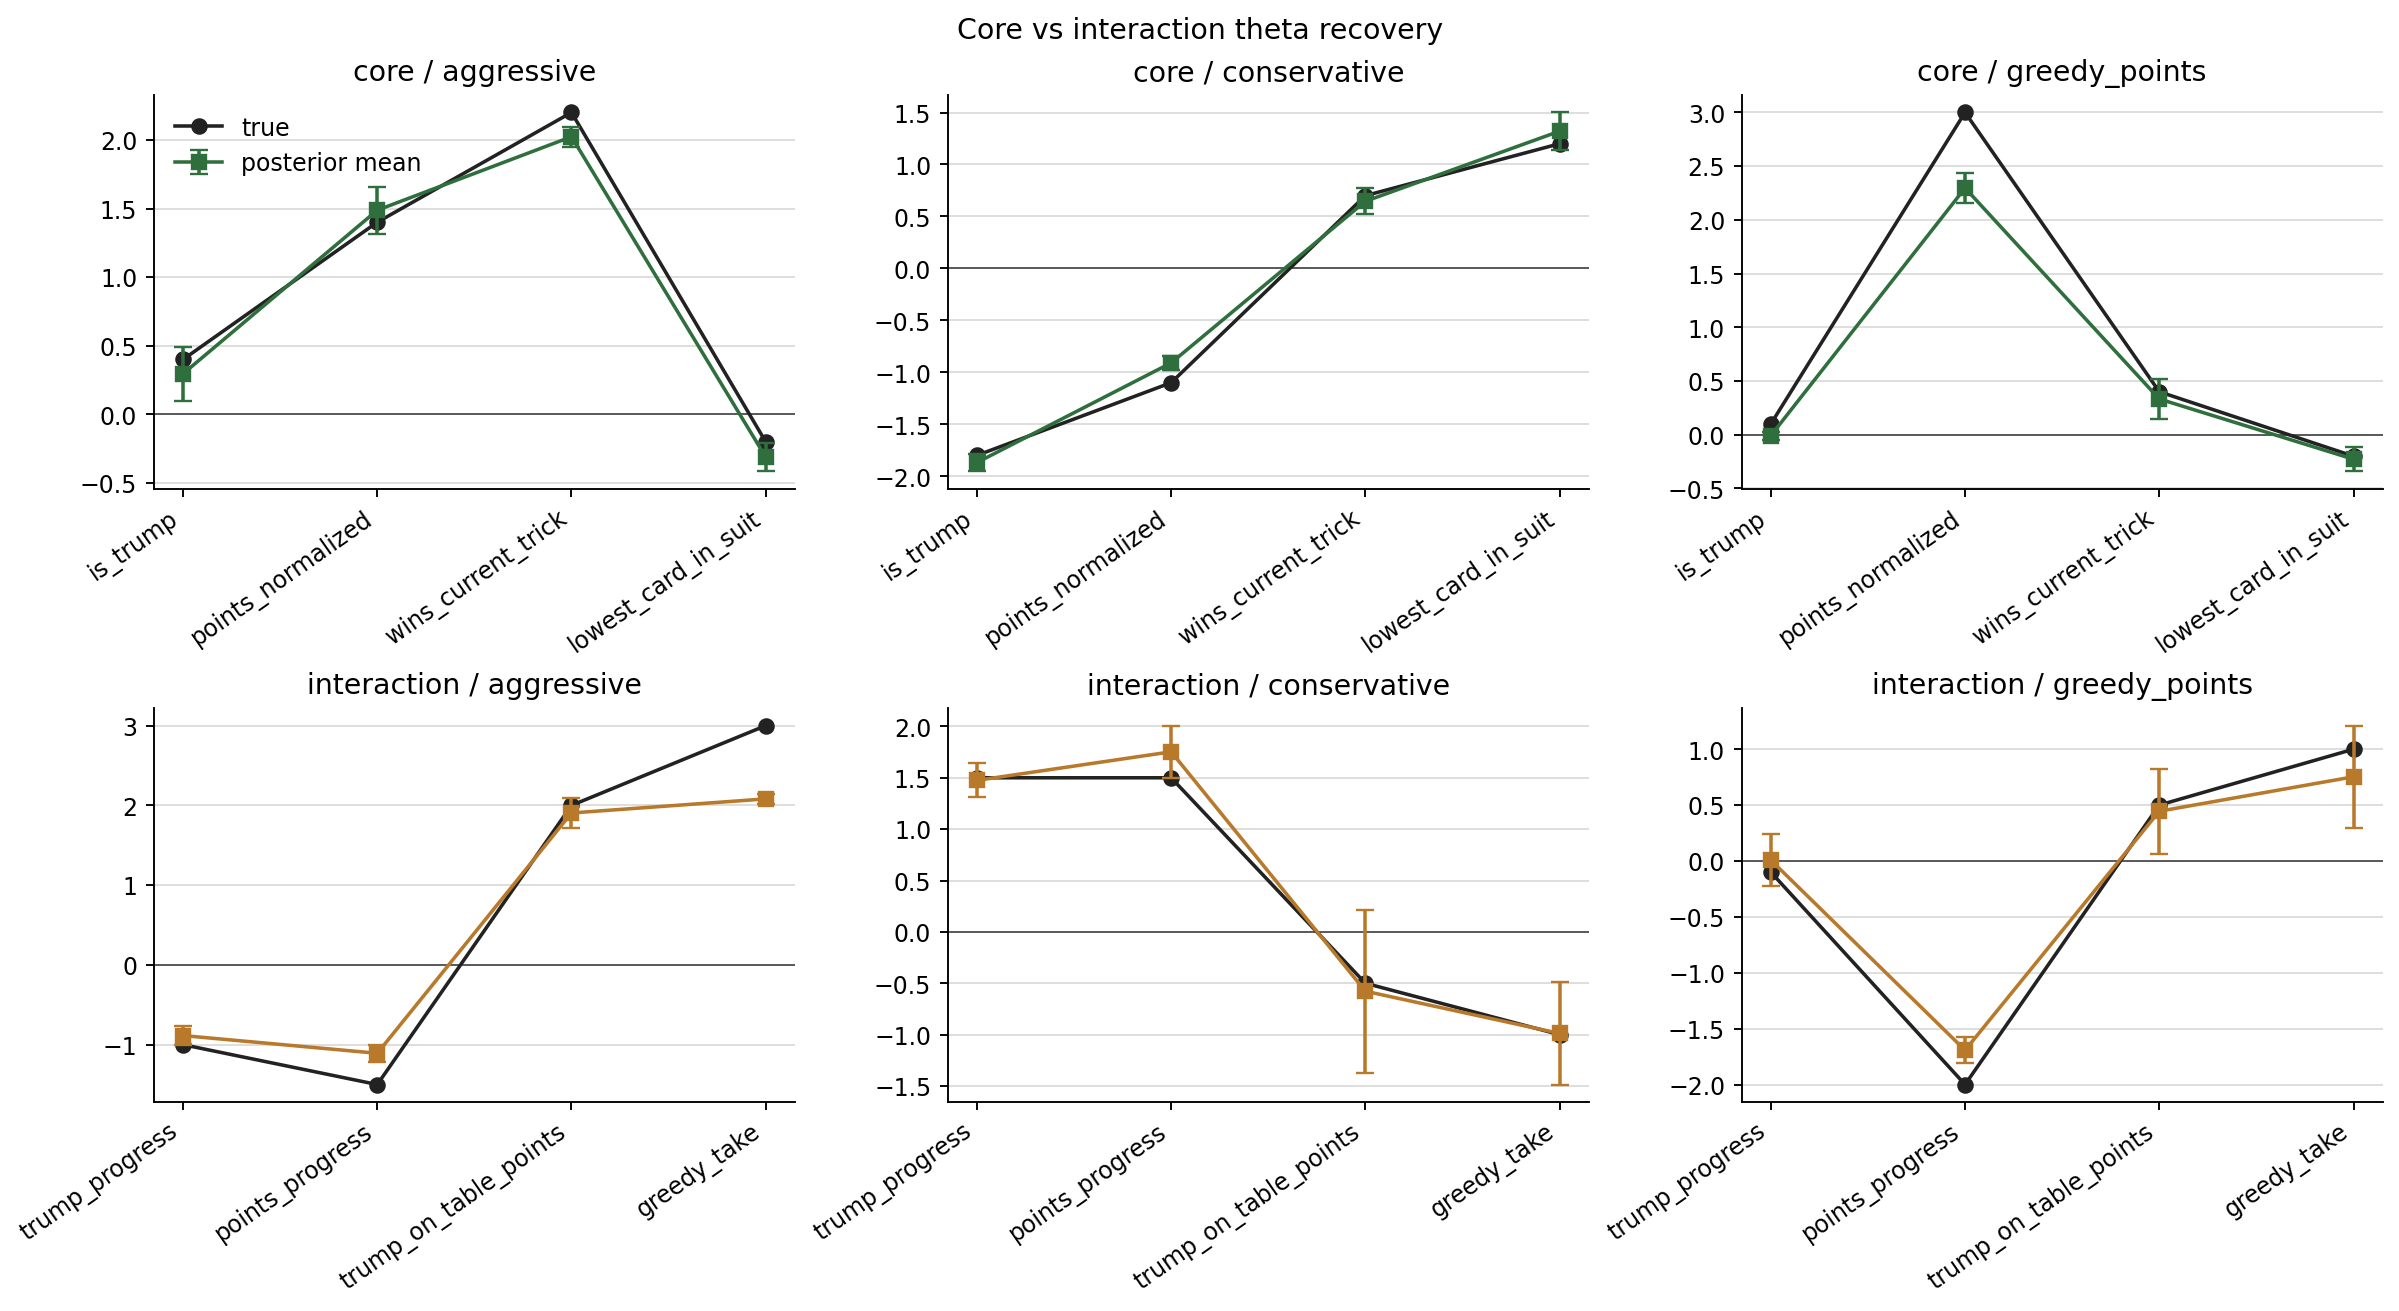

In [13]:
plot_theta_recovery(comparison_runs, feature_order, "Core vs interaction theta recovery")


## Reading

`core` is more stable on `aggressive` and `conservative`. `interaction` remains useful on `greedy_points`, where the context-only features capture part of the point-taking behavior.